In [168]:
import pandas as pd
import os, sys
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
import matplotlib.ticker as mtick


In [2]:
# Constants
parent_folder  = "results"
all_files = glob.glob(os.path.join(parent_folder, "*.csv"))
HEADERS = ["Epoch", "sources", "malign", "ban_sources", "ban_malign", "consensus", "rep_benign", "rep_malign"]
print("Found {} results".format(len(all_files)))

_DISCARD_ = True
_REPLACE_ = True

Found 1920 results


In [3]:
rc_params = {
    'font.size': 26,
    'legend.fontsize': 12,
    'legend.title_fontsize': 14,
    'figure.figsize': (7, 5),
    'axes.facecolor': '#FFFFFF',
    'figure.dpi': 300.0,
    'xtick.labelsize': 14.0,
    'ytick.labelsize': 14.0,
    'axes.labelsize': 16.0,
    'figure.titlesize': 20
    }

sns.set_theme(style='ticks', rc=rc_params)

sns.set_palette(sns.cubehelix_palette(n_colors=3, light=0.8, start=2))

# https://colorbrewer2.org/#type=diverging&scheme=PuOr&n=4

# plt.rcParams.keys()

In [14]:
print("Import results...")
_li = []
for filename in tqdm(all_files):
    _df = pd.read_csv(filename, index_col=None, header=None, names=HEADERS)
    _params = os.path.splitext(filename)[0].split("_")
    _df['rep_min'] = float(_params[1])
    _df['ratio_malign'] = float(_params[2])
    _df['alpha'] = float(_params[3])
    _df['tolerance'] = float(_params[4])
    _df['repetition'] = float(_params[5])
    _df['Algorithm'] = float(_params[6])
    _df['Arrival'] = _params[7]
    # Local Processing
    if float(_params[4]) == 3.0 and float(_params[5]) == 2 and float(_params[3]) == 0.5:
        _li.append(_df)
df = pd.concat(_li, axis=0, ignore_index=True)
print("We ended up with {} rows".format(len(df)))

Import results...


100%|██████████| 1920/1920 [00:32<00:00, 58.66it/s]


We ended up with 480000 rows


In [5]:
# Calculate Precision and Recall
print("Calculate precision and recall")
df['Recall'] = df.apply(lambda row: (row['ban_malign'] / row['malign'] if row['malign'] else 0), axis=1)
print("Recall done")
df['Precision'] = df.apply(lambda row: (row['ban_malign'] / row['ban_sources'] if row['ban_sources'] else 0), axis=1)
print("Precision done")


Calculate precision and recall
Recall done
Precision done


In [15]:
# Calculate Consensus Accuracy
GROUND_TRUTH = 25
df['Consensus Accuracy'] = df.apply(lambda row: (1 if abs(row['consensus'] - GROUND_TRUTH) < row['tolerance'] else 0), axis=1)
print("Consensus Accuracy done")
df_def = df.drop(df[df.Algorithm != 2].index)
#df_good = df.drop(df[df['Consensus Accuracy'] == 0].index)


Consensus Accuracy done


In [10]:
# Reduce dataset for tests XXX
# df_def = df.drop(df[df.repetition > 0].index)
# df_def = df_def.drop(df_def[df_def.alpha == 0.3].index)

array([0.        , 1.        , 0.91666667, ..., 0.88454707, 0.88475177,
       0.88495575])

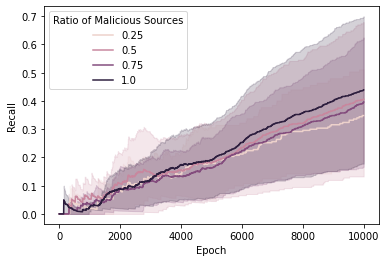

In [14]:
# PLOT 1 [ DISCARD PLOT ] - RECALL OVER TIME
# How many malicious sources I manage to kick out over time.
# The "ratio of malignous sources" is the discriminant here
img_name = "num_mal_over_time.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='ratio_malign')
        plt.legend(title='Ratio of Malicious Sources', loc='upper left')
        plt.savefig(img_name, dpi=300)
        print (img_name + "Done")

Doing min_rep_over_time.png
min_rep_over_time.pngDone


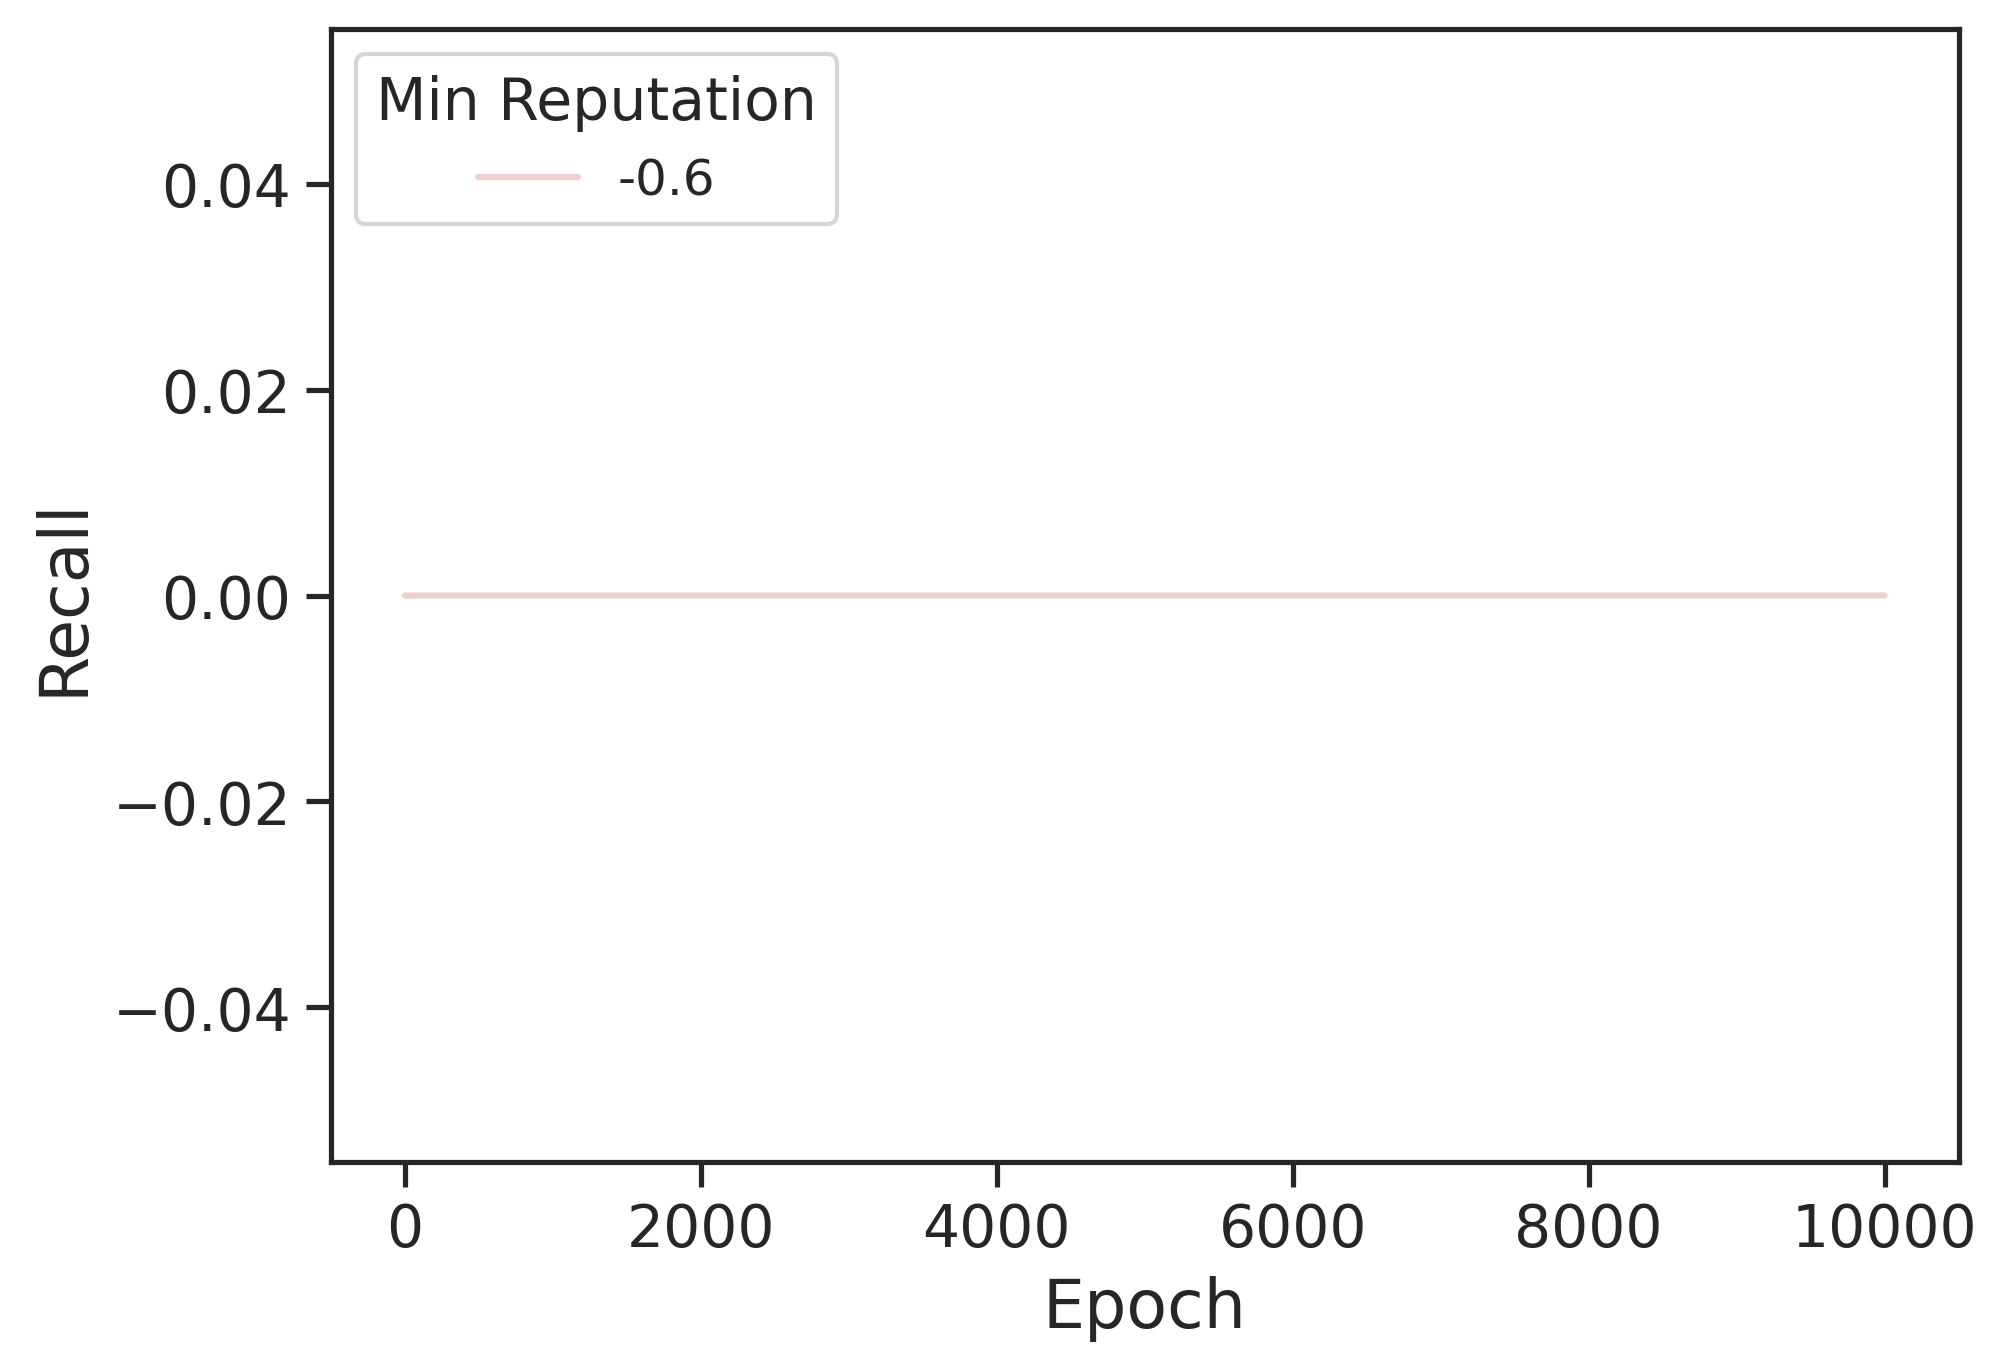

In [18]:
# PLOT 1 - RECALL OVER TIME
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "min_rep_rec_over_time.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    sns.lineplot(data=df_def, x='Epoch', y='Recall', hue='rep_min')
    plt.legend(title='Min Reputation', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

In [7]:
# PLOT 1 - PRECISION OVER TIME
# How many malicious sources I manage to kick out over time.
# The "min reputation" is the discriminant here
img_name = "min_rep_prec_over_time.png"
if _REPLACE_ or not os.path.exists(img_name):
    sns.lineplot(data=df_def, x='Epoch', y='Precision', hue='rep_min')
    plt.legend(title='Min Reputation', loc='upper left')
    plt.savefig(img_name, dpi=300)
    # plt.show()
    print (img_name + "Done")

IndentationError: unexpected indent (731449446.py, line 5)

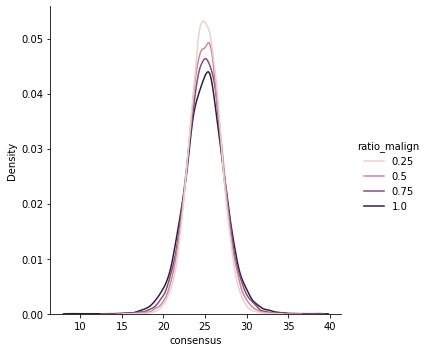

In [11]:
# PLOT 2 [DISCARD PLOT] - IMPACT ON CONSENSUS
# How is the consensus close to the ground truth
img_name = "pdf_consensus_num_mal.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.displot(data=df_def, x='consensus', hue='ratio_malign', kind='kde')
        # plt.legend(title='Ratio Malicious', loc='upper left')
        plt.savefig(img_name, dpi=300)
        # plt.show()
        print (img_name + "Done")

No handles with labels found to put in legend.


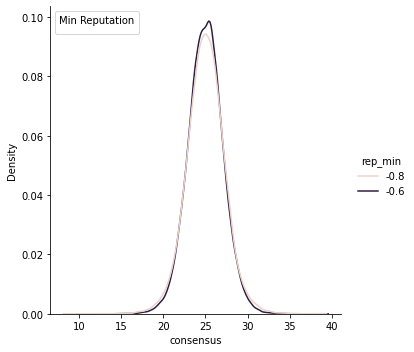

In [21]:
# PLOT 2 [DISCARD PLOT] - IMPACT ON CONSENSUS
# How is the consensus close to the ground truth
img_name = "pdf_consensus_min_rep.png"
if not _DISCARD_:
    if _REPLACE_ or not os.path.exists(img_name):
        sns.displot(data=df_def, x='consensus', hue='rep_min', kind='kde')
        # plt.legend(title='Ratio Malicious', loc='upper left')
        plt.savefig(img_name, dpi=300)
        # plt.show()
        print (img_name + "Done")

Doing algorithm_comparison_bursty.png
algorithm_comparison_bursty.png Done!


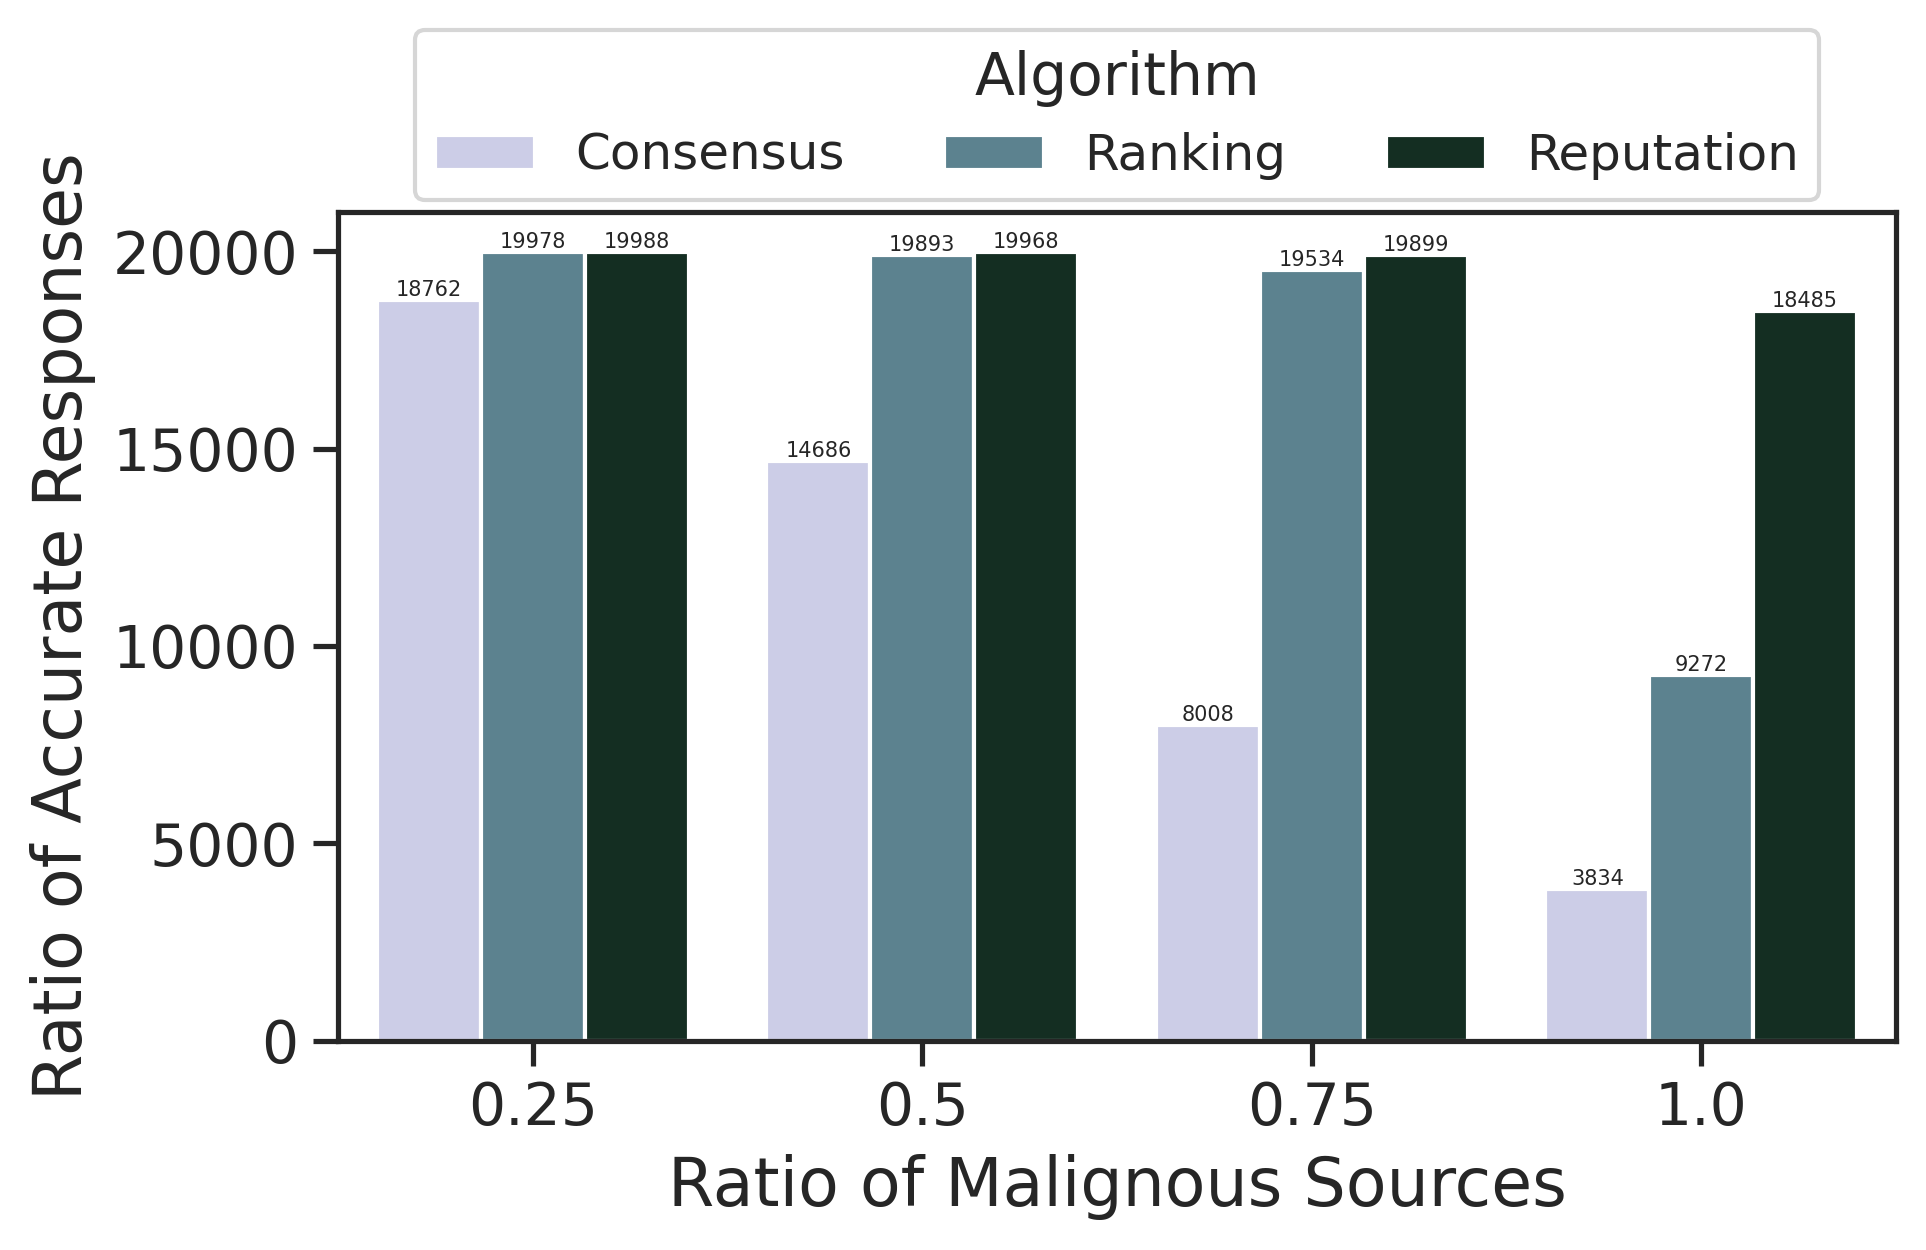

In [60]:
# PLOT 2 - IMPACT ON CONSENSUS ACCURACY

# Comparison of this algo with another dummy one ? Only one bar !
# Average - no kick out
# Median - with ranking - no kick out

img_name = "algorithm_comparison_bursty.png"
if (_REPLACE_ or not os.path.exists(img_name)) and not _DISCARD_:
    print("Doing " + img_name)
    ax = sns.countplot(data=df_good, x='ratio_malign', hue='Algorithm')
    for i in ax.containers:
        ax.bar_label(i, fontsize=5)
    plt.legend(title='Algorithm', loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=3,
    labels=['Consensus', 'Ranking', 'Reputation'])
    ax.set_xlabel('Ratio of Malignous Sources', fontsize=16)
    ax.set_ylabel('Ratio of Accurate Responses', fontsize=16)

    plt.tight_layout()
    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")


In [77]:
print("Doing the bars...")
df_bar = df.groupby(['rep_min', 'ratio_malign', 'Algorithm', 'Arrival'])['Consensus Accuracy'].agg(['sum','count']).reset_index()
df_bar['Accuracy'] = df_bar.apply(lambda x: float(x['sum']) / float(x['count']) , axis=1)
df_bar['ratio_malign'] = df_bar.apply(lambda x: float(x['ratio_malign'] / 2 * 100.0), axis=1)


df_bar = df_bar.groupby(['ratio_malign', 'Algorithm', 'Arrival'])['Accuracy'].agg(['mean','std']).reset_index()


,ratio_malign,Algorithm,Arrival,mean,std
0,12.5,0.0,bursty,0.94625,0.015022
1,12.5,0.0,uniform,0.96430,0.001114
2,12.5,1.0,bursty,0.99805,0.000252
3,12.5,1.0,uniform,0.99895,0.000300
4,12.5,2.0,bursty,0.99910,0.000258
5,12.5,2.0,uniform,0.99975,0.000191
6,25.0,0.0,bursty,0.75305,0.037152
7,25.0,0.0,uniform,0.81730,0.009108
8,25.0,1.0,bursty,0.98990,0.002176
9,25.0,1.0,uniform,0.99565,0.001050


(0.0, 1.1)

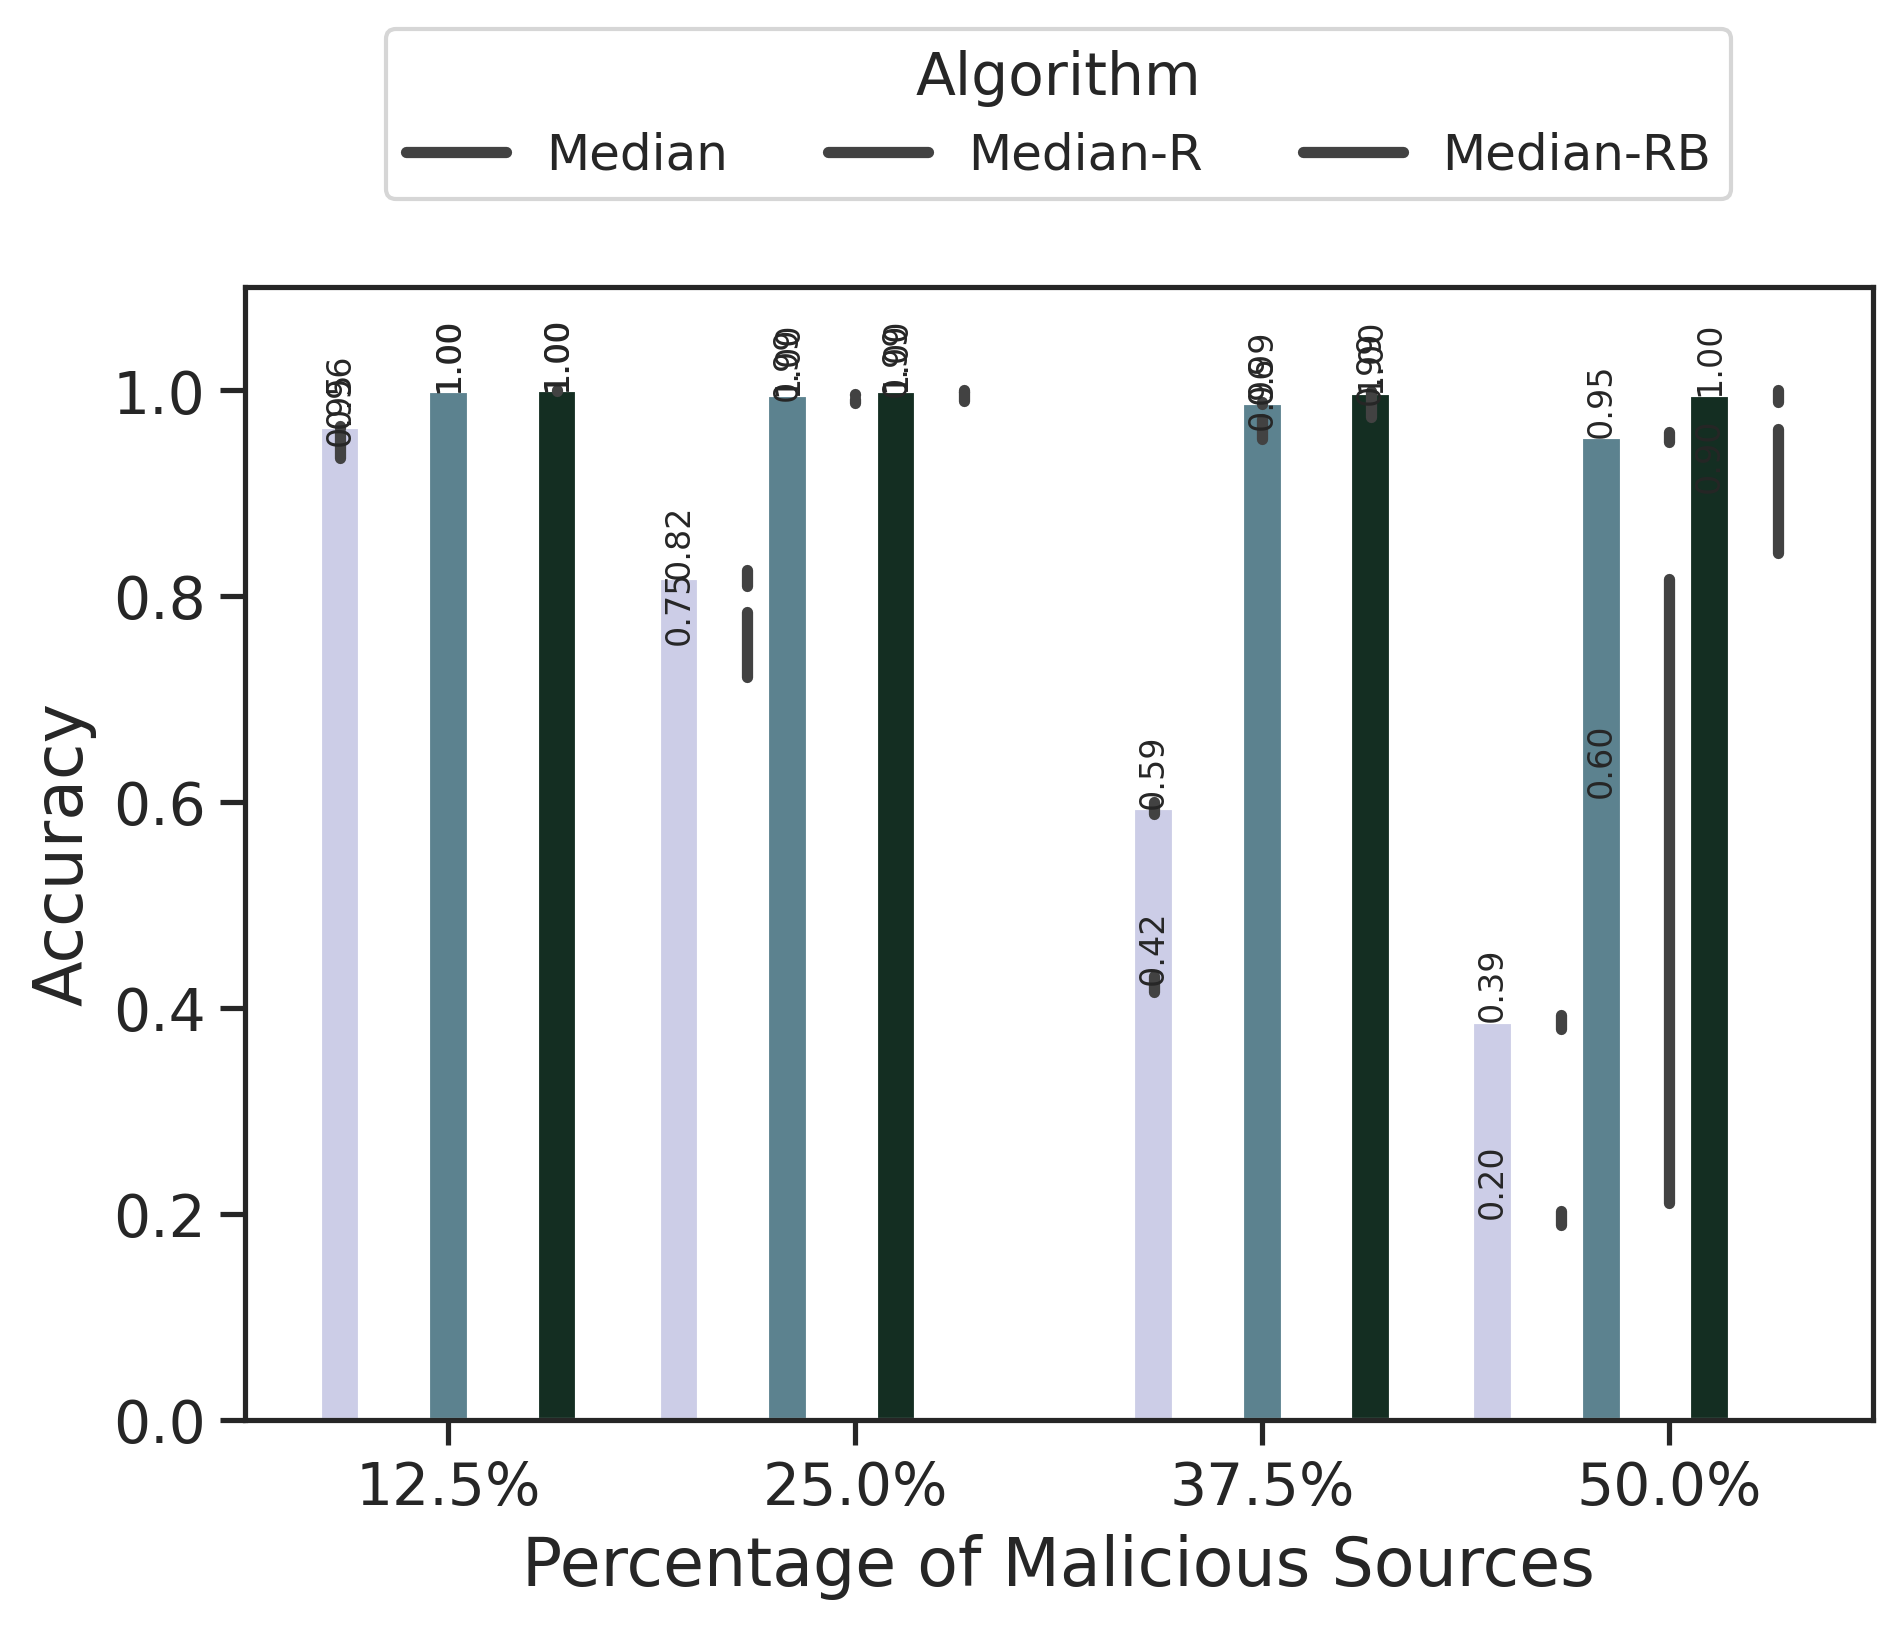

In [69]:
# ax = sns.barplot(data=df_bar[df_bar['Arrival'] == 'bursty'], x="ratio_malign", y="Accuracy", hue="Algorithm")
# bx = sns.barplot(data=df_bar[df_bar['Arrival'] == 'uniform'], x="ratio_malign", y="Accuracy", hue="Algorithm")



# for i in ax.containers:
#     ax.bar_label(i, fmt='%.2f', rotation=90, fontsize=8)


# plt.legend(title='Algorithm', loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=3,
# labels=['Median', 'Median-R', 'Median-RB'])
# ax.set_xlabel('Percentage of Malicious Sources', fontsize=16)
# ax.set_ylabel('Accuracy', fontsize=16)
# ax.set_xticklabels([str(x).split("\'")[1]+'%' for x in ax.get_xticklabels()])
# plt.ylim([0,1.1])

/tmp/ipykernel_42961/2346526444.py:23: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
/tmp/ipykernel_42961/2346526444.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()


desmo_accuracy.png Done!


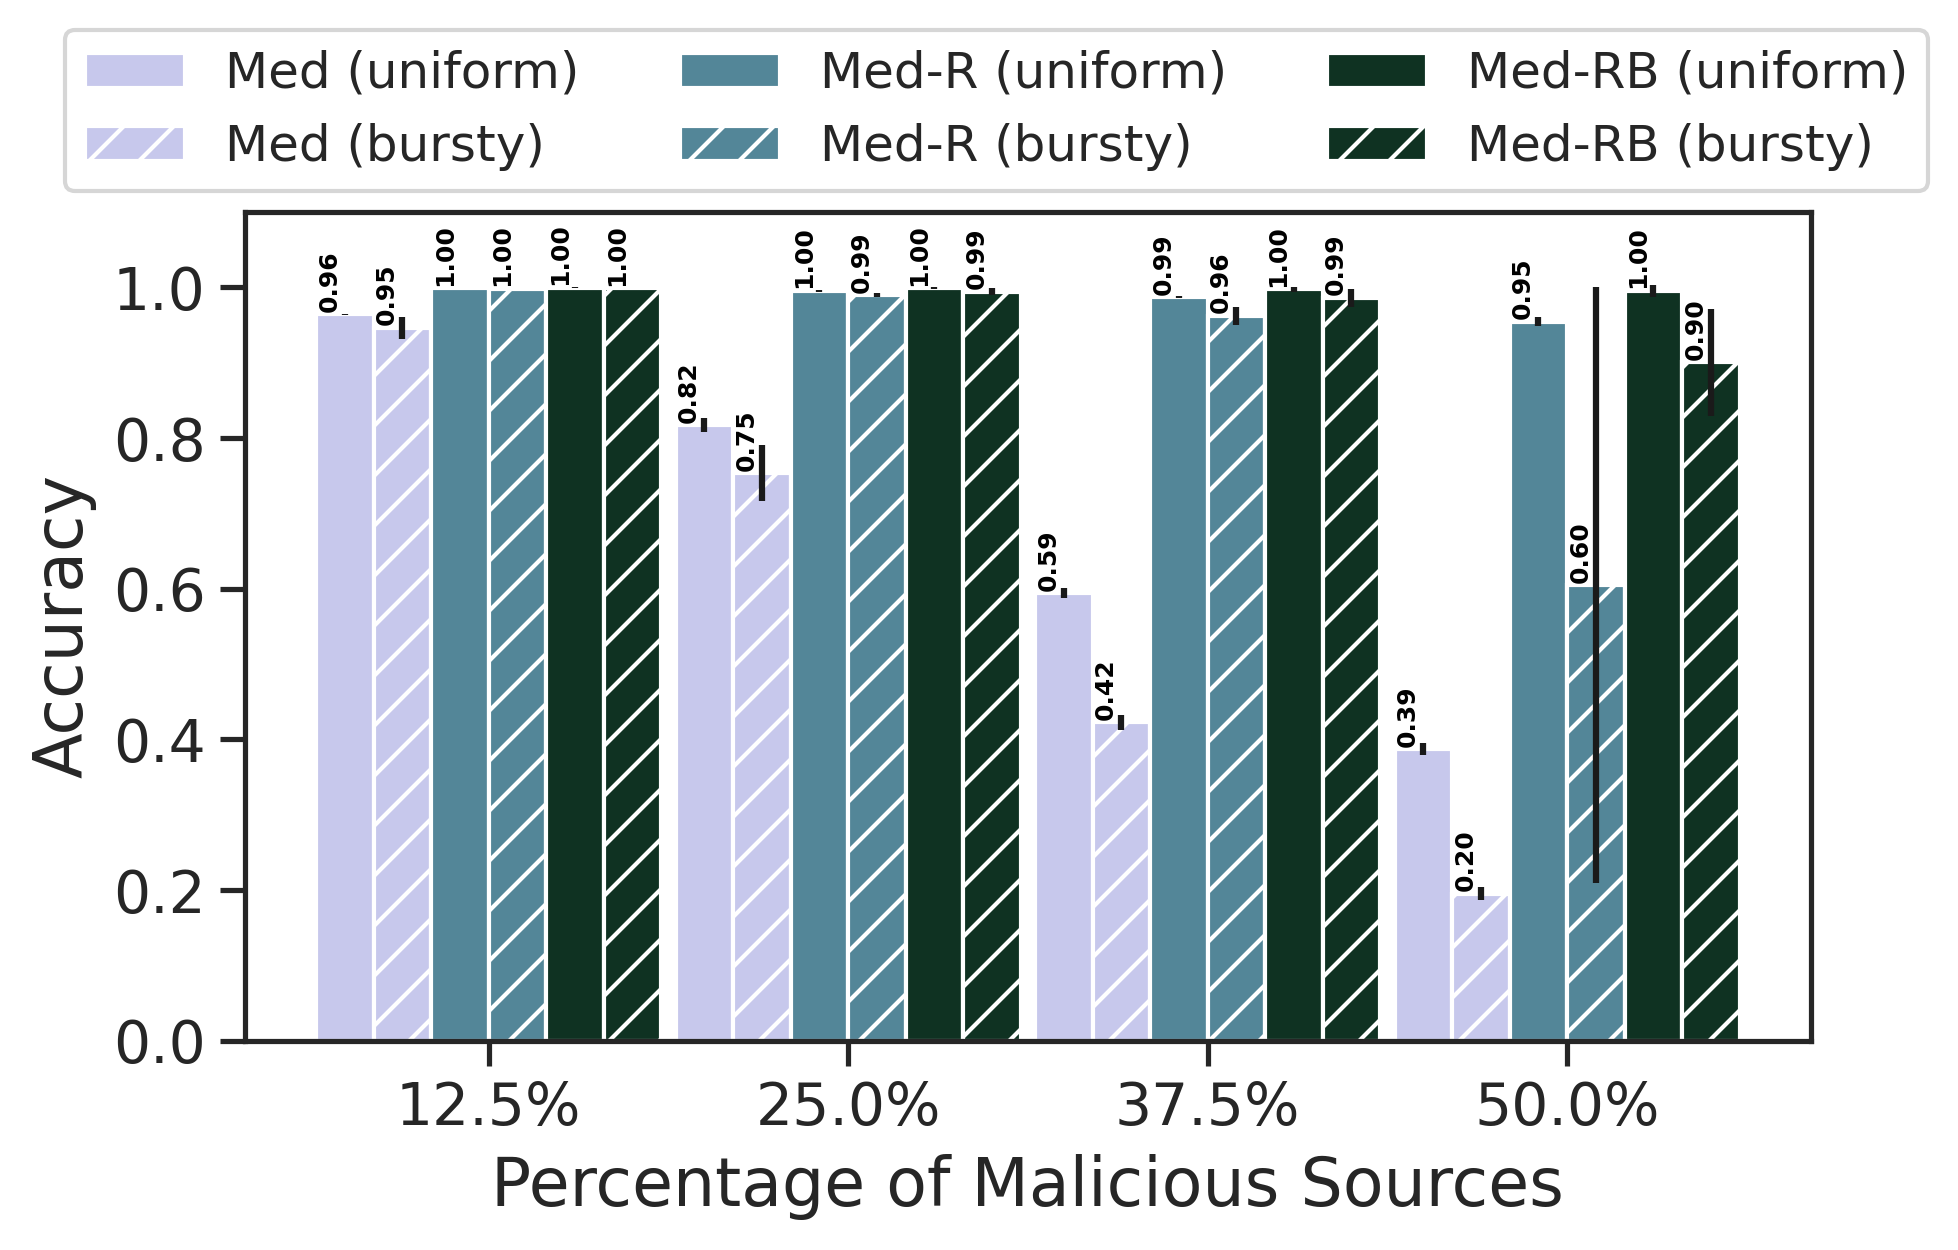

In [171]:
img_name = "desmo_accuracy.png"
if _REPLACE_ or not os.path.exists(img_name):
    print ("Doing " + img_name)
    xvals = df_bar['ratio_malign'].unique()
    algos = df_bar['Algorithm'].unique()
    arrs = np.flip(df_bar['Arrival'].unique())

    width = 2

    colors = sns.cubehelix_palette(n_colors=3, light=0.8, start=2) # ['r', 'g', 'b']
    hatches = ['','//']

    fig, ax  = plt.subplots()

    plt.xticks(xvals)
    xvals = xvals - (len(algos) * len(arrs) * width / 2) - (width/2)
    plt.xlabel('Percentage of Malicious Sources', fontsize=16)
    plt.ylabel('Accuracy', fontsize=16)
    plt.rcParams['mathtext.default'] = 'regular'
    for i, algo in enumerate(algos):
        for j, arr in enumerate(arrs):
            xvals = xvals + width
            xlist = xvals.tolist()
            yvals = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['mean'].tolist()
            yerrs = df_bar[df_bar['Arrival'] == arr][df_bar['Algorithm'] == algo]['std'].tolist()
            plt.bar(xvals, yvals, color = colors[i], width = width, label = str(algo)+str(arr), hatch=hatches[j], yerr=yerrs)
            for h in range(len((yvals))):
                ax.text(xlist[h] - width/2 + 0.05, yvals[h] + 0.01, str('{0:.2f}'.format(yvals[h])), rotation=90, fontsize=6, color='black', fontweight='bold')
            # for pos, y, err in zip(xvals, yvals, yerrs):
            #     ax.errorbar(pos, y, err, lw = 2,
            #                 capsize = 4, capthick = 2,
            #                 color = "red")
    plt.legend(loc='upper center', bbox_to_anchor=(0.48, 1.25), ncol=3, labels=['Med (uniform)', 'Med (bursty)', 'Med-R (uniform)', 'Med-R (bursty)', 'Med-RB (uniform)', 'Med-RB (bursty)'])
    plt.ylim([0,1.1])
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
    plt.tight_layout()
    # plt.show()
    plt.savefig(img_name, dpi=200)
    print(img_name + " Done!")

KeyboardInterrupt: 

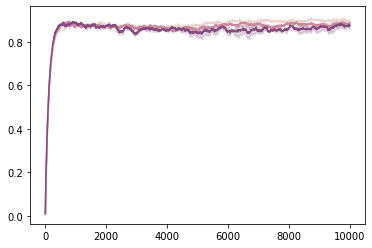

In [22]:
# df_use = df_def
# df_good = df_use.drop(df[df.repetition > 0].index)


# # PLOT 1
# sns.lineplot(data=df_def, x='Epoch', y='rep_benign', hue='ratio_malign')
# sns.lineplot(data=df_def, x='Epoch', y='rep_malign', hue='ratio_malign')
# plt.legend(title='Ratio malicious', loc='upper left')
# #plt.savefig("min_rep_over_time.png", dpi=300)
# plt.show()